# Shunique - Company Background
Shunique is a hot new online women's shoe company that is known for their unique shoe combinations.  Founded by auto tire amgnate Joseph Flatbush and his daugthers Jenna and Jamaica.  He believed that just like car tires, women's shoes should be unique and stylish. However, a bold choice to release a "silver vegan leather sandal" that had very few sales has left the company to turn towards their data in search of the next big shoe hit.  The company doesn't know much about their data and have not been keeping up with their monthly, quarterly, and yearly performance.    You were hired as a data analyst to help them answer key questions.  You were given all the shoe sales transactions from Aug 2018 to Aug 2020.  They do know a few statistics:  (1) They have generated \$166,936,995 in total sales since opening (2) The top 3 cities for number of shoes sold are Washington, DC, Houston, Tx, and El Paso, Tx (See Figure below).  They have also provided you with a codebook describing all the columns and their potential values.
<img src="num_shoes_sold_per_city.png">

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/ars370/Downloads/Module_5__Capstone_export_2/capstone_cohort_3/transactions.csv")

df.head(5)

,first_name,last_name,email,city,address,state,transactionDate,transactionID,time,quantity,name,color,materials,prices,feature,category,cost,Date
0,Ximenes,Oxshott,xoxshott0@biglobe.ne.jp,Idaho Falls,5 Pearson Plaza,Idaho,04/04/2019,6e3e9c86-2251-44bc-8249-8045e5406cca,7:07 PM,2,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,119.90,2019-04-04
1,Urson,Wilcox,uwilcox2w@weather.com,Lima,8 Muir Road,Ohio,02/03/2019,aaacafb6-112c-41ad-baf1-44b54b17170b,3:21 AM,1,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,59.95,2019-02-03
2,Svend,De la Feld,sdelafeld58@last.fm,Wilmington,0 5th Pass,Delaware,07/21/2019,3727a9ae-9914-421c-9adc-eb4f1dd010f4,5:04 AM,2,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,119.90,2019-07-21
3,Laura,Potts,bmartin@scott-carr.info,Rodriguezmouth,03918 Rachel Meadows Apt. 214,Wisconsin,01/26/2019,649691c5-a77f-4ae2-bee1-4894a03b2dd3,06:26 PM,1,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,59.95,2019-01-26
4,Alicia,Barker,wduarte@yahoo.com,Port Elijah,5407 Conrad Divide,Arizona,12/13/2019,140995b6-91f1-465f-9491-c7413112a9ee,03:07 AM,5,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,299.75,2019-12-13


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105257 entries, 0 to 1105256
Data columns (total 18 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   first_name       1105257 non-null  object 
 1   last_name        1105257 non-null  object 
 2   email            1105257 non-null  object 
 3   city             1105257 non-null  object 
 4   address          1105257 non-null  object 
 5   state            1105257 non-null  object 
 6   transactionDate  1105257 non-null  object 
 7   transactionID    1105257 non-null  object 
 8   time             1105257 non-null  object 
 9   quantity         1105257 non-null  int64  
 10  name             1105257 non-null  object 
 11  color            1105257 non-null  object 
 12  materials        1105257 non-null  object 
 13  prices           1105257 non-null  float64
 14  feature          1071074 non-null  object 
 15  category         1105257 non-null  object 
 16  cost             1

In [4]:
#Convert date and transactionDate to date/time Dtype

df['Date'] = pd.to_datetime(df['Date'])
df['transactionDate'] = pd.to_datetime(df['transactionDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105257 entries, 0 to 1105256
Data columns (total 18 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   first_name       1105257 non-null  object        
 1   last_name        1105257 non-null  object        
 2   email            1105257 non-null  object        
 3   city             1105257 non-null  object        
 4   address          1105257 non-null  object        
 5   state            1105257 non-null  object        
 6   transactionDate  1105257 non-null  datetime64[ns]
 7   transactionID    1105257 non-null  object        
 8   time             1105257 non-null  object        
 9   quantity         1105257 non-null  int64         
 10  name             1105257 non-null  object        
 11  color            1105257 non-null  object        
 12  materials        1105257 non-null  object        
 13  prices           1105257 non-null  float64       
 14  fe

In [5]:
df.head(3)

,first_name,last_name,email,city,address,state,transactionDate,transactionID,time,quantity,name,color,materials,prices,feature,category,cost,Date
0,Ximenes,Oxshott,xoxshott0@biglobe.ne.jp,Idaho Falls,5 Pearson Plaza,Idaho,2019-04-04,6e3e9c86-2251-44bc-8249-8045e5406cca,7:07 PM,2,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,119.90,2019-04-04
1,Urson,Wilcox,uwilcox2w@weather.com,Lima,8 Muir Road,Ohio,2019-02-03,aaacafb6-112c-41ad-baf1-44b54b17170b,3:21 AM,1,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,59.95,2019-02-03
2,Svend,De la Feld,sdelafeld58@last.fm,Wilmington,0 5th Pass,Delaware,2019-07-21,3727a9ae-9914-421c-9adc-eb4f1dd010f4,5:04 AM,2,'waffle Spa Slide' Slipper (women),green,leather,59.95,recycled material,wedges,119.90,2019-07-21


# Assignment Questions for the Captone Project Analyzing "Shunique - Company Background" Data Using Python and Tableau

## Question 1
 
**Definition of Quarters:**
January, February, and March (Q1)
April, May, and June (Q2)
July, August, and September (Q3)
October, November, and December (Q4) 

### **(1a.)** What was the name of the Best selling shoe and total sales for the Second Fiscal Quarter(Q2) of 2020?

The Best selling shoe in 2020 was the **Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3**. The total sales for the Second Fiscal Quarter (Q2) of 2020 was **$203,485,02.18**

In [6]:
# Filtering the data to only contain dates in Q2 2020
Q2_2020 = df[df.transactionDate.between('04/01/2020', '6/30/2020')]

# Adding up the total sales and grouping by each shoe name
group_by_name = Q2_2020.groupby('name')
agg = group_by_name.agg({'cost':'sum'})
agg.sort_values(by='cost', ascending=False)

,cost
name,
Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3,102480.00
Yu&yu Women's Shoes Round Toe Chunky Heel Oxfords Shoes More Colors Available,69030.60
Diamond Eternity Band,62984.85
Yu&yu Women's Shoes Pointed Toe Flat Heel Flats Shoes More Colors Available,54738.24
Yu&yu Women's Shoes Round Toe Low Heel Oxfords Shoes More Colors Available,45935.19
...,...
Bella Vita Sangria Women Us 7.5 N/s White Wedge Sandal Blemish 1903,16.83
Nina Falana-vg Women Us 6 Silver Sandals Pre Owned 1904,16.83
Alfani Hannia Women Us 8.5 Gold Thong Sandal Pre Owned 1904,15.84


In [7]:
# Calculating total sales for Q2 2020
Q2_2020_total_sales = Q2_2020.cost.sum()

print(Q2_2020_total_sales)

20348502.18


### **(1b)**. How did it compare to that shoe's sales in 2019 Q2?  Is it the hottest selling shoe in Q2 2019?  What else can you say about the Q2 2019 versus Q2 2020 performance of this shoe relative to other top sellers during these quarters? 

The Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3 generated **$102,480 in Q2 2020**, which is exactly the same as its sales in Q2 2019. In Q2 2019, it was the third-highest seller behind the **Diamond Eternity Band (the hottest selling shoe during this period)** and the Yu&yu Women's Shoes Round Toe Chunky Heel Oxfords Shoes More Colors Available. It seems that the boot rose to the top in sales not because it's own sales activity increased, but instead because its competitors performed poorly in Q2 2020.

In [8]:
# Filtering the data to only contain dates in Q2 2019
Q2_2019 = df[df.transactionDate.between('04/01/2019', '06/30/2019')]

# Adding up the total sales and grouping by each shoe name
group_by_name = Q2_2019.groupby('name')
agg = group_by_name.agg({'cost': 'sum'})
agg.sort_values(by = 'cost', ascending=False)

,cost
name,
Diamond Eternity Band,138566.67
Yu&yu Women's Shoes Round Toe Chunky Heel Oxfords Shoes More Colors Available,133459.16
Mirak Womens 12482-18788 Khaki Lace Up Waterproof Walking Boot 3,102480.00
Yu&yu Women's Shoes Round Toe Low Heel Oxfords Shoes More Colors Available,74371.26
'pebbles' Tall Gladiator Pump (women),59800.00
...,...
"Trotters 1650 Womens Black Patent Leather Heels Pumps Shoes 7 Wide (c,d,w) Bhfo",16.83
Mix No 6 Sarti Women Us 8 Green Platform Heel Pre Owned 1650,16.83
Kensie Veronica Women Us 8.5 Blue Sneakers Pre Owned 1906,15.84


## Question 2

Over the life of the collected data,

### **(2a)** What state has the highest total sales?  

**Texas generated $4,046,697.79** in total sales, making it the highest performer of all the states.

In [9]:
# Calculating the sum of total sales and grouping the results by state
(df.
 groupby('state').
 agg({'cost': 'sum'}).
 sort_values('cost', ascending=False).
 head(5)
)

,cost
state,
Texas,4046697.79
California,4040519.98
Florida,3915786.35
New York,3711601.23
Virginia,3506240.78


### **(2b)** Which state/district/terrritory sold the most shoes over this same period?  

**Texas** not only generated the most sales but also sold the most shoes over the same period. They sold a total of **27,128 shoes**, the highest of all the states. 

In [10]:
#Calculating the total quantity of shoes sold and grouping the results by state
(df.
 groupby('state').
 agg({'quantity':'count'}).
 sort_values('quantity', ascending=False).
 head(5)
)

,quantity
state,
Texas,27128
California,26882
Florida,25339
New York,24072
Virginia,22895


### **(2c)** Which state/district/terrritory sold the least number of shoes over this period?

**The District of Columbia only sold 1,707 shoes**, the least of all the states in the same period.

In [11]:
# #Calculating the total quantity of shoes sold and grouping the results by state, then displaying in ascending order

(df.
 groupby('state').
 agg({'quantity':'count'}).
 sort_values('quantity', ascending=True).
 head(5)
)

,quantity
state,
District of Columbia,1707
Hawaii,20960
Maine,21006
Alaska,21016
Wyoming,21026


## Question 3
Jenna Flatbush wants to know what combination of shoes to introduce into low-performing cities.  You came up with the idea that they should start marketing combinations that are already selling well.

### **(3.)** What combination of attributes have the most sales? [ color, materials, feature, category ]

The combination of shoe attributes that have the most sales are the **black, leather, travel friendly, wedges**

In [12]:
#Calculating the total sales of shoes and grouping by color, material, feature, and category

df.groupby(['color', 'materials', 'feature', 'category'])[['cost']].agg('sum').sort_values('cost', ascending=False)

cost
color    materials feature           category           
black    leather   travel friendly   wedges    881131.43
         rubber    diabetic approved wedges    713090.00
         leather   padding           heels     523562.83
metallic nubuck    strappy           wedges    473800.00
black    leather   wearable tech     sandals   409756.96
...                                                  ...
silver   leather   vegan             loafers      180.18
black    manmade   wide toe box      gym          174.24
gold     nubuck    wide toe box      heels        152.46
beige    suede     moisture wicking  sandals      146.52
yellow   manmade   insulated         soccer       138.60

[6800 rows x 1 columns]

## Question 4

Jamaica Flatbush is unsure of how Shunique performed last year (2019). 

### **(4a)** What were total sales? in 2019

The total sales made in 2019 were **$87,005,120.81**

In [13]:
#Filtering data to only capture sales in 2019
sales_2019 = df[(df.transactionDate >= '2019-01-01') & (df.transactionDate <= '2019-12-31')]

#Calculating the total sales in 2019
sales_2019_total = sales_2019.agg({'cost':'sum'})

print(sales_2019_total)

cost    87005120.81
dtype: float64


### **(4b)** Plot daily, monthly, quarterly sales for 2019.

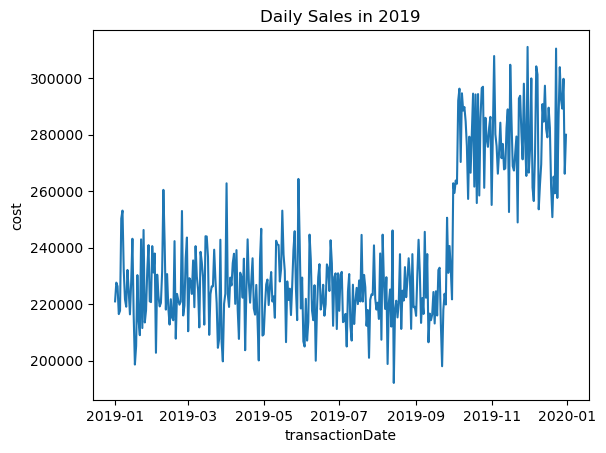

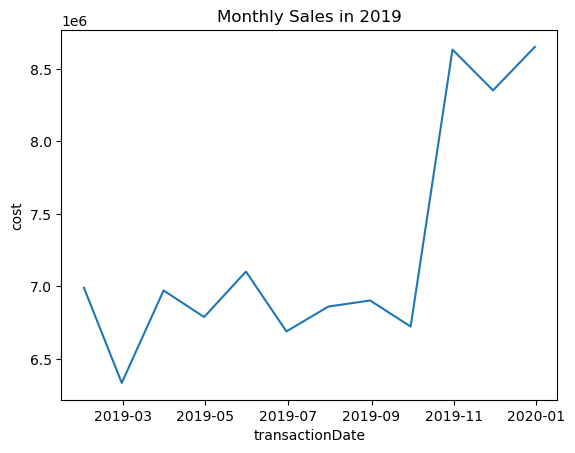

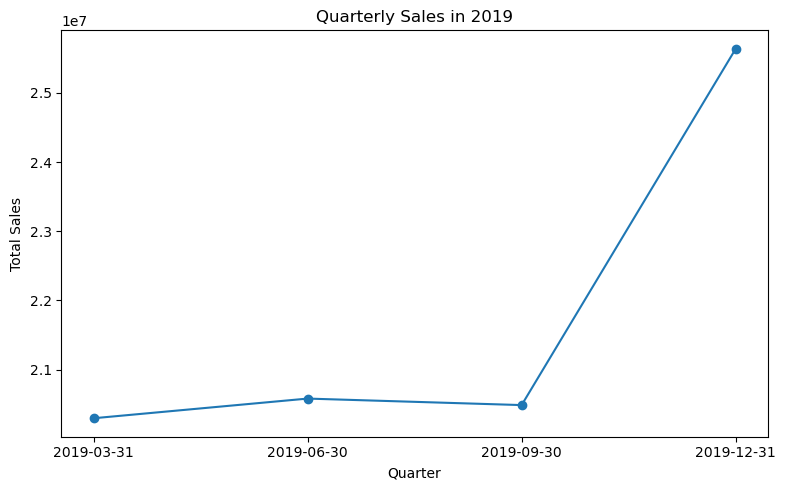

In [14]:
# Daily sales in 2019
sales_2019_daily = sales_2019.groupby(pd.Grouper(key='transactionDate', freq='D')).agg({'cost':'sum'})

sns.lineplot(
    data=sales_2019_daily, x='transactionDate', y='cost')
plt.title('Daily Sales in 2019')
plt.show()

# Monthly sales in 2019
sales_2019_monthly = sales_2019.groupby(pd.Grouper(key='transactionDate', freq='ME')).agg({'cost':'sum'})

sns.lineplot(
    data=sales_2019_monthly, x='transactionDate', y='cost')
plt.title('Monthly Sales in 2019')
plt.show()

# Quarterly sales in 2019
sales_2019_quarter = sales_2019.groupby(pd.Grouper(key='transactionDate', freq='QE')).agg({'cost':'sum'})

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sales_2019_quarter.index.astype(str), sales_2019_quarter.values, marker='o')

ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales")
ax.set_title("Quarterly Sales in 2019")
plt.tight_layout()
plt.show()

### (4c) Are there any trends? 

Yes, there is a **sharp increase in sales beginning in November 2019 that lasts through the end of the year.**

### (4d) In the monthly sales data, describe a significant event (ie. increase or decrease in sales) and hypothesize(make a wild guest) about its existence? What additional evidence(data) would be needed to support or negate your hypothesis.

There is a **sharp increase in sales beginning in the month of November 2019 that lasts through the remainder of the year.** My hypothesis to explain this spike in sales data is a result of the holiday season beginning. Customers begin to buy gifts for their family members and friends in November to deliver during the many holidays that occur in December.

In order to support or negate this hypothesis, additional data collected in each sales transaction could include an indication of a sales receipt requested upon purchase. Typically, when customers are buying items for others as gifts, a gift receipt is requested so as the item can be returned or replaced by the person receiving the item.

## Question 5

A key metric for retail sales data is Average Purchase Value(APV).  APV measures the average value of each purchase made by your customers and will often compare that to the average number of units per transaction(ANU). The formula for APV is (Total Sales Revenue / Number of Customers or Transactions)

### **(5a).** Calculate the Average Purchase Value for Q1 and Q4 of 2019.

The average purchase value in **Q1 2019 was $146.75**

The average purchase value in **Q4 2019 was $182.46**

In [15]:
#Filtering data to only capture purchases in Q1 2019
Q1_2019 = df[df.transactionDate.between('01/01/2019', '03/31/2019')]

#Calculating the sales revenue and total transactions
total_sales_revenue_Q1_19 = Q1_2019.cost.sum()
total_transactions_Q1_19 = Q1_2019.cost.count()

#Calculating the APV
Q1_APV = (total_sales_revenue_Q1_19/total_transactions_Q1_19)

print(f"The Average Purchase Value for Q1 in 2019 is ${Q1_APV:.2f}")

The Average Purchase Value for Q1 in 2019 is $146.75


In [16]:
#Filtering data to only capture purchases in Q4 2019
Q4_2019 = df[df.transactionDate.between('10/01/2019', '12/31/2019')]

#Calculating the sales revenue and total transactions
total_sales_revenue_Q4_19 = Q4_2019.cost.sum()
total_transactions_Q4_19 = Q4_2019.cost.count()

#Calculating the APV
Q4_APV = (total_sales_revenue_Q4_19/total_transactions_Q4_19)

print(f"The Average Purchase Value for Q4 in 2019 is ${Q4_APV:.2f}")

The Average Purchase Value for Q4 in 2019 is $182.46


### **(5b).** Calculate the average number of units per transaction for Q1 and Q4

The average number of units per transaction in **Q1 for 2019 was 1.55.**
The average number of units per transaction in **Q4 for 2019 was 1.90**

In [17]:
#Filtering data to only capture purchases in Q1 2019
Q1_2019 = df[df.transactionDate.between('01/01/2019', '03/31/2019')]

#Calculating the total units sold and total transactions
total_units_sold_Q1_2019 = Q1_2019.quantity.sum()
total_transactions_Q1_2019 = Q1_2019.quantity.count()

#Calculating the ANU
Q1_ANU = (total_units_sold_Q1_2019/total_transactions_Q1_2019)

print(f"The average number of units per transaction for Q1 2019 is {Q1_ANU:.2f}")

The average number of units per transaction for Q1 2019 is 1.55


In [18]:
#Filtering data to only capture purchases in Q4 2019
Q4_2019 = df[df.transactionDate.between('10/01/2019', '12/31/2019')]

#Calculating the total units sold and total transactions
total_units_sold_Q4_2019 = Q4_2019.quantity.sum()
total_transactions_Q4_2019 = Q4_2019.quantity.count()

#Calculating the ANU
Q4_ANU = (total_units_sold_Q4_2019/total_transactions_Q4_2019)

print(f"The average number of units per transaction for Q4 is {Q4_ANU:.2f}")

The average number of units per transaction for Q4 is 1.90


### **(5c).** Describe the differences between Q1 and Q4 values.  Speculate on possible causes for differences(Hint: Seasonality)

There is a clear increase in both the average number of units (APU) per transaction and the average purchase value (APV) from Q1 to Q4 in 2019. The APV rises from $146.75 in Q1 to $$182.46 in Q4, indicating that customers spent more per transaction later in the year. Similarly, the APU, increases from 1.55 units in Q1 to 1.90 units in Q4, showing that customers purchased a greater quantity of items per order.

A likely explanation for these differences is seasonality. Q4 encompasses major shopping periods due to the holiday season, where consumers tend to buy more items and make larger purchases due to promotions and gift-giving. In contrast, Q1 most likely experienced a slow down as consumers recover from holiday spending.

## Question 6

Shunique is looking to expand its distribution centers so that it can outperform Zappos on delivery time to customers.  It is important to know what states and regions are epicenters for high sales and you have been asked to present the following results.

### **(6a)** Report 2020 Sales by state - Present results tabularly 

In [19]:
#Filtering data to only show transactions in 2020
sales_2020 = df[(df.transactionDate >= '2020-01-01') & (df.transactionDate <= '2020-12-31')]

#Calculating the total sales grouped by state
(sales_2020.
 groupby('state').
 agg({'cost': 'sum'}).
 sort_values('cost', ascending = False)
)

,cost
state,
Texas,1238215.58
California,1219721.54
Florida,1143359.72
New York,1074477.72
Ohio,1021461.58
Virginia,1009027.82
Oklahoma,996220.92
Washington,994863.51
Georgia,988708.06


## **(6b)** In Tableau create a Map visualization of total sales(2018 - 2020) by Region [Northeast, West, Midwest, South].

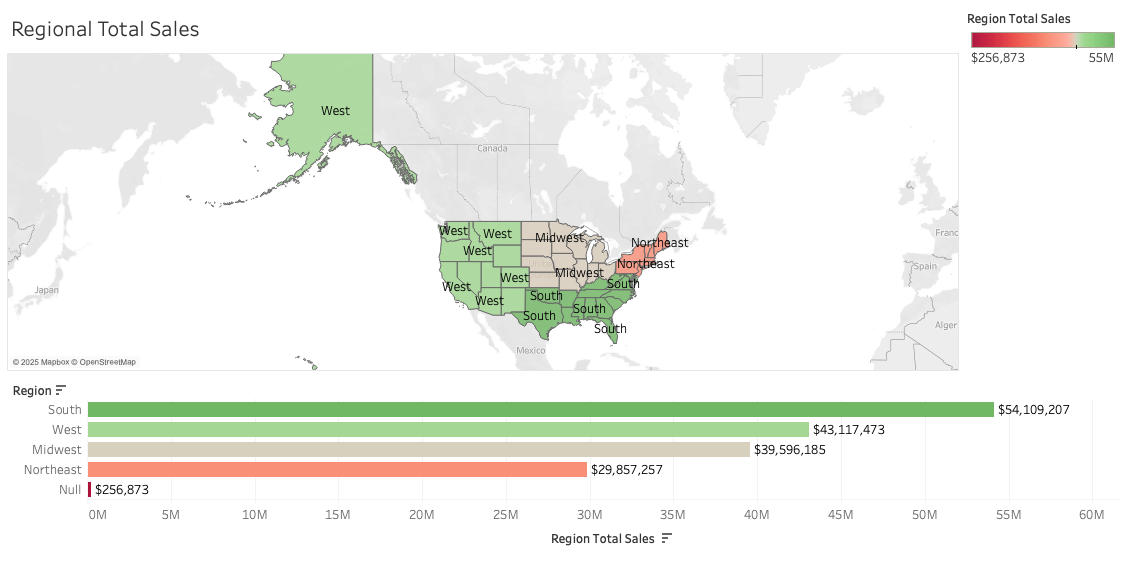

## Question 7

### Use any type of plot to show the distribution of prices for the following shoe colors ('metallic', 'bronze', 'animal print', 'yellow')

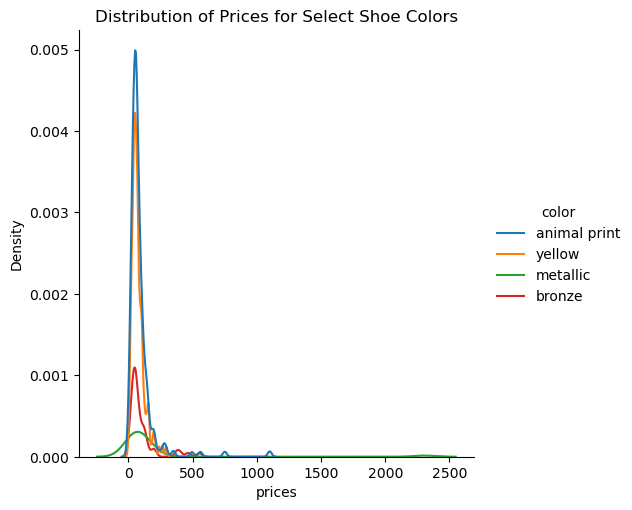

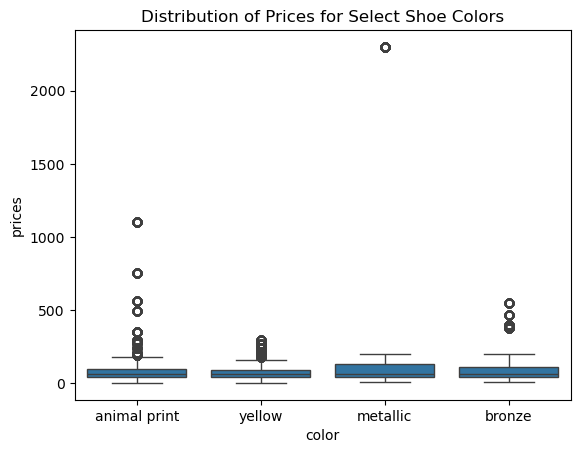

In [20]:
#Filtering the colors we want to display
select_colors = ['metallic', 'bronze', 'animal print', 'yellow']

filtered_colors = df[df['color'].isin(select_colors)]

#Creating a histogram to display the data
sns.displot(data=filtered_colors, x='prices',
            hue='color', kind='kde')
plt.title('Distribution of Prices for Select Shoe Colors')
plt.show()

#Creating a boxplot to display the data
sns.boxplot(data=filtered_colors, x='color', y='prices')
plt.title('Distribution of Prices for Select Shoe Colors')
plt.show()

## Question 8

The Shunique marketing team is desperate to find the next big shoe hit.  They have asked for your help. 

### **(8a)** Select a unique combination of shoe attributes then create a summary report with various statistics (ie Average sales price, city with most sales, quarter with most shoes sold, Customer name with highest purchase, etc)[it is your choice].  If the shoe combo doesn't exist in the dataset then choose another combination. Next quarter they are going to release an animal print, leather, strappy, basketball shoe.  

(Summary statistics found below!)

In [21]:
# Choosing a unique combination of shoe attributes
combo = df[
    (df['color'] == 'green') &
    (df['materials'] == 'leather') &
    (df['category'] == 'wedges')
]

# Checking to see if that unique shoe combination exists
combo.shape[0] 

# Renaming the filtered dataset by the unique shoe combination
filtered_combo = df[
    (df['color'] == 'green') &
    (df['materials'] == 'leather') &
    (df['category'] == 'wedges')
].copy()

#Seeing how many results we have with this combo
filtered_combo.shape

(1236, 18)

In [22]:
# Creating summary statistics for the shoe combo (green leather wedges)

# Average sales price
avg_price = filtered_combo['prices'].mean()

# City with the most sales
top_city = filtered_combo['city'].value_counts().idxmax()

# Quarter with the most shoes sold
filtered_combo['quarter'] = filtered_combo['transactionDate'].dt.to_period('Q')
top_quarter = filtered_combo['quarter'].value_counts().idxmax()

# Customer with the highest total purchase amount
filtered_combo['customer_name'] = filtered_combo['first_name'] + ' ' + df['last_name']
top_customer = filtered_combo.groupby('customer_name')['prices'].sum().idxmax()

print("Summary Report for Selected Shoe Attributes Combination")
print("Combo: Green leather wedges")
print(f"Total records: {filtered_combo.shape[0]}")
print(f"Average sales price: ${avg_price:.2f}")
print(f"City with the most sales: {top_city}")
print(f"Quarter with the most shoes sold: {top_quarter}")
print(f"Customer with the highest total purchase amount: {top_customer}")

Summary Report for Selected Shoe Attributes Combination
Combo: Green leather wedges
Total records: 1236
Average sales price: $85.20
City with the most sales: West Christopher
Quarter with the most shoes sold: 2019Q3
Customer with the highest total purchase amount: Anthony Johnson


## Question 9

### **(9a)** Are there opportunities to grow sales?  

Yes, the data suggests several clear opportunities to grow sales. First, because Q4 shows a sharp increase in purchase value and units per transaction, than in Q1, there is evidence of strong seasonal demand that the business can potentially extend or promote earlier in the year. Strategies such as targeted promotions, product branding or loyalty incentives during slower periods could help close the gap between quarters.

### **(9b)** Are there products that you would discontinue? 

Based on the data, there are several products, or product combinations that show very low total sales, suggesting they could be considered for discontinuation. In the grouped results from earlier, many shoes with combinations such as **silver leather vegan loafers, black manmade wide toe box gym shoes, gold nubuck heels, beige suede moisture-wicking sandals, and yellow manmade insulated soccer shoes** have extremely low sales. In some cases, a shoe combination has less than $200 worth of sales over the three years of data captured.

### **(9c)** What other datasets would you use to complement the transaction data and why?

To compliment transaction data and gain a deeper understanding of business performance, an additional dataset containing customer demographics could be helpful. Information such as age, gender, and income level could guide targeted marketing. Additional datasets such as website data could also be beneficial. Data related to click-though rates, search behavior, abandoned carts, and ad campaign data would reveal interest levels and consumer behavior. This could help identify products with high interest and inform website layout to ensure these high demand and high performing items are easy to find online.

## Question 10

The sales team is asking for increased bonuses because they increased daily sales year-over-year. 

### **(10)** Calculate the daily sales totals (cost) for the date ranges 8/1/2018-7/31/2019 and 8/1/2019-7/31/2020. Describe and compare the two distributions (center, variability, spread, and anomalies). Create a graphical display that makes this easy to understand.

The 2018-2019 distribution centers around **$210,000-220,000**. The 2018-2019 daily totals also appear more compact and slightly skewed left, with almost no extreme daily totals meaning the sales were very consistent.

While the 2019-2020 distribution shifts notably higher, with a center closer to **$230,000-245,000** indicating a stronger daily revenue performance in 2019-2020. The 2019-2020 daily totals are more right-skewed towards higher performing days, with even some unusual high outliers. These higher outliers show more business growth from the previous period in 2018-2019.

In [23]:
# Creating both date ranges
date_range_1 = df[(df.transactionDate >= '2018-08-01') & (df.transactionDate <= '2019-07-31')]
date_range_2 = df[(df.transactionDate >= '2019-08-01') & (df.transactionDate <= '2020-07-31')]

# Daily sales total for the first date range
daily_1_sum = (
    date_range_1.groupby(pd.Grouper(key='transactionDate', freq='D')).agg({'cost':'sum'}))

# Daily sales total for the second date range
daily_2_sum = (
    date_range_2.groupby(pd.Grouper(key='transactionDate', freq='D')).agg({'cost':'sum'}))

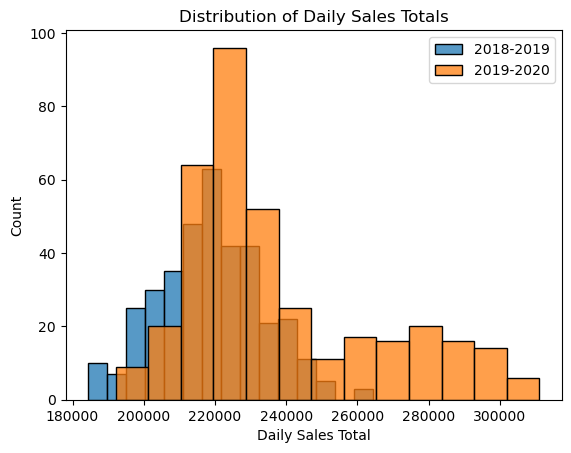

In [24]:
# Creating a graphical display in the form of a histogram to understand how the distribution of daily sales varies by each date range
ax = sns.histplot(daily_1_sum['cost'], label="2018-2019", kde=False)
sns.histplot(daily_2_sum['cost'], label="2019-2020", kde=False)
ax.set(xlabel="Daily Sales Total", ylabel="Count", title="Distribution of Daily Sales Totals")
plt.legend()
plt.show()

## Question 11

Looking at the summary, the CEO says the sales don't look that different. 

### **(11)** Is the difference in sales statistically significant enough to justify increased bonuses? (Answer using inference, either a significance test or comparison of confidence intervals)

Yes, the difference in sales between the two periods is highly statistically significant. The two-sample t-test revealed a p-value of 3.1466556982150907e-28 which is very far below the significance level of 0.05. This means that the probability that the observed difference between the two periods happened randomly by chance is essentially zero. Additionally, the 95% confidence intervals for the two periods do not align. In 2018-2019 the interval is **217,422 to 220,495,** while the 2019-2020 interval sits far above the first year at **234,982 to 240,544.** This shows that the average daily sales increased by a meaningful margin. For all of these reasons, the CEO should increase bonsuses.

In [25]:
from scipy import stats

#Finding the p-value for two these periods of time
stats.ttest_ind(daily_1_sum['cost'], daily_2_sum['cost'], equal_var=False)

TtestResult(statistic=np.float64(-11.63815231954758), pvalue=np.float64(3.1466556982150907e-28), df=np.float64(568.5543653965846))

In [26]:
import statsmodels.stats.api as sms

#Comparing the confidence intervals
summary_daily_1 = sms.DescrStatsW(daily_1_sum['cost'])
print(f'95% confidence interval for the first date range: {summary_daily_1.tconfint_mean()}')
summary_daily_2 = sms.DescrStatsW(daily_2_sum['cost'])
print(f'95% confidence interval for the second date range: {summary_daily_2.tconfint_mean()}')

95% confidence interval for the first date range: (np.float64(217421.81478457258), np.float64(220494.88768795476))
95% confidence interval for the second date range: (np.float64(234981.80634085034), np.float64(240544.17928756474))
